# AI Referee v2Prototype — high-confidence foul override

v2Prototype keeps the crop-based RTMW-X skeleton, camera/track reset protection,
SAM 2 masks, MoGe-2 metric geometry, and every-frame V4.11 detector.

New rule:

> If the restored image fusion itself says `FOUL` and fused evidence is at
> least 97%, one frame is sufficient to call a foul. This bypasses the normal
> consecutive-frame requirement and the metric 3D veto.

The threshold is exposed in the final run cell as
`HIGH_CONFIDENCE_OVERRIDE`. Set it to `1.01` to disable the override.


## 1. Start a GPU runtime and install dependencies

In [1]:
!pip -q install "ultralytics>=8.3.0" "mediapipe>=0.10.30" opencv-python-headless av matplotlib scipy pillow rtmlib onnxruntime-gpu "transformers>=4.57.0" accelerate huggingface_hub
!pip -q install "git+https://github.com/microsoft/MoGe.git"

import os, sys
from pathlib import Path

PROJECT = Path("/content/ai-referee-v409")
(PROJECT / "airef").mkdir(parents=True, exist_ok=True)
(PROJECT / "runs").mkdir(parents=True, exist_ok=True)
os.chdir(PROJECT)
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))

import torch
print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

POSE_MODEL = PROJECT / "pose_landmarker_heavy.task"
if not POSE_MODEL.exists():
    !wget -q -O "$POSE_MODEL" "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/latest/pose_landmarker_heavy.task"
print("MediaPipe pose model:", POSE_MODEL)


import getpass
if not os.environ.get("ROBOFLOW_API_KEY"):
    os.environ["ROBOFLOW_API_KEY"] = getpass.getpass(
        "Roboflow PRIVATE API key: "
    )
print("Roboflow key received (not displayed)")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.5/36.5 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.3/220.3 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 129.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Prepar

## 2. Write the trained image-MLP inference module

In [2]:
%%writefile airef/image_mlp.py
from __future__ import annotations

from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torchvision import models, transforms

DEFAULT_WEIGHTS = (
    Path(__file__).resolve().parents[1] / "runs/image_foul_mlp_v408.pt"
)
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]
EVAL_TF = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])


class MLPHead(nn.Module):
    def __init__(self, features=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(0.20),
            nn.Linear(features, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.30),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(32, 2),
        )

    def forward(self, features):
        return self.net(features)


def _device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def _model(device):
    model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
    model.fc = MLPHead(model.fc.in_features)
    return model.to(device).eval()


_CACHE = None


def load_model(weights=DEFAULT_WEIGHTS):
    global _CACHE
    path = Path(weights)
    if not path.exists():
        raise FileNotFoundError(f"Upload image_foul_mlp_v408.pt to {path}")
    if _CACHE is None or _CACHE["path"] != str(path):
        checkpoint = torch.load(path, map_location="cpu", weights_only=False)
        if checkpoint.get("format") != "resnet34_imagenet_delta_fp16_v1":
            raise ValueError("Wrong checkpoint: expected the V4.08/V4.09 model")
        device = _device()
        model = _model(device)
        delta = {
            key: value.float() if value.is_floating_point() else value
            for key, value in checkpoint["delta_state_dict"].items()
        }
        incompatible = model.load_state_dict(delta, strict=False)
        if incompatible.unexpected_keys:
            raise ValueError(f"Unexpected model keys: {incompatible.unexpected_keys}")
        _CACHE = {
            "path": str(path),
            "device": device,
            "model": model.eval(),
            "classes": list(checkpoint["classes"]),
            "metrics": dict(checkpoint.get("cross_validation", {})),
        }
    return _CACHE


def predict_bgr(images, weights=DEFAULT_WEIGHTS, batch_size=64):
    """Flip-TTA probabilities for a list of BGR images."""
    import cv2

    state = load_model(weights)
    if not images:
        return np.empty((0, 2), dtype=np.float32), state["classes"]
    output = []
    for start in range(0, len(images), batch_size):
        tensors = torch.stack([
            EVAL_TF(Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)))
            for image in images[start:start + batch_size]
        ]).to(state["device"])
        with torch.inference_mode():
            direct = torch.softmax(state["model"](tensors), dim=1)
            flipped = torch.softmax(
                state["model"](torch.flip(tensors, dims=[3])), dim=1
            )
        output.append((0.5 * (direct + flipped)).cpu().numpy())
    return np.concatenate(output), state["classes"]

Writing airef/image_mlp.py


## 2b. Restore the original detector and classifier modules

In [3]:
%%writefile airef/device.py
"""Device selection: CUDA (Colab) / MPS (Apple Silicon) / CPU.

Kept in one place so training, evaluation and inference agree. Apple's MPS
backend has no GradScaler and no stable fp16 autocast, so mixed precision is
enabled for CUDA only — on MPS we train in fp32, which is what the M-series
unified memory wants anyway.
"""
from __future__ import annotations

import os

import torch


def pick_device(prefer: str | None = None) -> str:
    """Return 'cuda', 'mps' or 'cpu'.

    Override with the AIREF_DEVICE env var (e.g. AIREF_DEVICE=cpu) when the
    MPS path misbehaves on a particular op.
    """
    choice = prefer or os.environ.get("AIREF_DEVICE")
    if choice:
        return choice
    if torch.cuda.is_available():
        return "cuda"
    if torch.backends.mps.is_available():
        return "mps"
    return "cpu"


def amp_enabled(device: str) -> bool:
    """Mixed precision is CUDA-only here (see module docstring)."""
    return device == "cuda"


def pin_memory(device: str) -> bool:
    """pin_memory only means anything for CUDA host->device copies."""
    return device == "cuda"


def dataloader_workers(device: str) -> int:
    """macOS spawns (not forks) workers; 2 is fine and keeps decode off the main thread."""
    return 2


Writing airef/device.py


In [4]:
%%writefile airef/roboflow_client.py
"""Binary foul / no-foul detection via the team's Roboflow workflow (REST).

Why REST and not the official `inference-sdk`: every published inference-sdk
release requires Python < 3.13 and this project runs 3.13, so the SDK cannot
be installed. The serverless REST endpoint is Roboflow's documented fallback
and needs no extra dependencies.

Why the child workflow and not the "...Logic" wrapper: the wrapper
(football-foul-detection-vfootball-foul-detection-u1r8g-1-rfdetr-medium-t1-logic)
is broken server-side — its inner_workflow step binds a `model_id` parameter
that the child workflow does not declare, so every run returns HTTP 500
(InnerWorkflowParameterBindingsUnknownInputError). The child workflow
`football-foul-detection-u1r8g` is the actual model run and works. Fix the
wrapper in the Roboflow UI and you can pass its slug via `workflow_id=`.

The API key comes from the ROBOFLOW_API_KEY environment variable, or from a
git-ignored `.env` file at the repo root. Never hardcode or commit it.

Grounded response shape (captured from a real run, 2026-07-18 — see
runs/roboflow_ground/):

    {"outputs": [{"predictions": {
        "image": {"width": W, "height": H},
        "predictions": [{"x":..,"y":..,"width":..,"height":..,
                         "confidence":..,"class":"fouling_player"|"victim"|"foul",
                         "class_id":..,"detection_id":..,"parent_id":..}, ...]}}],
     "profiler_trace": []}
"""
from __future__ import annotations

import base64
import json
import os
import time
import urllib.error
import urllib.request
from dataclasses import dataclass, field
from pathlib import Path

API_URL = "https://serverless.roboflow.com"
WORKSPACE = "ishmeet-singh-csaoh"
DEFAULT_WORKFLOW = "football-foul-detection-u1r8g"

# Soccer-specific ball detector (RF-DETR-small). The "...-logic" wrapper works
# for this one, but we target the child workflow for consistency with the foul
# client and to avoid the inner_workflow binding class of bug.
BALL_WORKFLOW = "soccer-ball-detection-2-teahj"

# Detection classes that signal a foul event (the model also emits "victim").
FOUL_CLASSES = frozenset({"foul", "fouling_player"})


class RoboflowError(RuntimeError):
    """Request or response-shape failure talking to Roboflow."""


class RoboflowAuthError(RoboflowError):
    """Bad or missing API key."""


@dataclass
class Detection:
    cls: str
    confidence: float
    x: float
    y: float
    width: float
    height: float


@dataclass
class FoulCall:
    """Binary verdict for one image.

    confidence is a heuristic: the strongest foul-class detection when foul,
    else 1 - the strongest sub-threshold foul-class detection (1.0 if none).
    """
    foul: bool
    confidence: float
    detections: list[Detection] = field(default_factory=list)
    image_wh: tuple[int, int] = (0, 0)


def _api_key() -> str:
    key = os.environ.get("ROBOFLOW_API_KEY")
    if not key:
        env_file = Path(__file__).resolve().parents[1] / ".env"
        if env_file.exists():
            for line in env_file.read_text().splitlines():
                name, _, value = line.strip().partition("=")
                if name == "ROBOFLOW_API_KEY" and value:
                    key = value.strip().strip("'\"")
                    break
    if not key:
        raise RoboflowAuthError(
            "ROBOFLOW_API_KEY not set (env var or .env at the repo root). "
            "Get it at app.roboflow.com/settings/api."
        )
    return key


def _to_base64(image: str | Path | bytes) -> str:
    data = image if isinstance(image, bytes) else Path(image).read_bytes()
    return base64.b64encode(data).decode()


def run_foul_workflow(
    image: str | Path | bytes,
    workflow_id: str = DEFAULT_WORKFLOW,
    timeout: float = 60.0,
    retries: int = 2,
) -> tuple[list[Detection], tuple[int, int]]:
    """Run one image through the workflow; return (detections, (width, height)).

    Retries transient failures (network errors, HTTP 5xx) with exponential
    backoff. 4xx errors don't retry; 401/403 raise RoboflowAuthError.
    """
    body = json.dumps({
        "api_key": _api_key(),
        "inputs": {"image": {"type": "base64", "value": _to_base64(image)}},
    }).encode()
    url = f"{API_URL}/{WORKSPACE}/workflows/{workflow_id}"

    last_err: Exception | None = None
    for attempt in range(retries + 1):
        try:
            req = urllib.request.Request(
                url, data=body, headers={"Content-Type": "application/json"}
            )
            with urllib.request.urlopen(req, timeout=timeout) as r:
                resp = json.load(r)
            break
        except urllib.error.HTTPError as e:
            detail = e.read().decode(errors="replace")[:300]
            if e.code in (401, 403):
                raise RoboflowAuthError(f"HTTP {e.code}: {detail}") from e
            if 400 <= e.code < 500:
                raise RoboflowError(f"HTTP {e.code}: {detail}") from e
            last_err = RoboflowError(f"HTTP {e.code}: {detail}")
        except (urllib.error.URLError, TimeoutError, json.JSONDecodeError) as e:
            last_err = RoboflowError(f"request failed: {e}")
        if attempt < retries:
            time.sleep(0.5 * 2 ** attempt)
    else:
        raise last_err  # type: ignore[misc]

    # Defensive parse against the grounded shape; never assume, never keep blobs.
    try:
        block = resp["outputs"][0]["predictions"]
        # width/height come back as null (not absent) when the model finds
        # nothing in the image, so `or {}` / `or 0` — not .get defaults.
        img = block.get("image") or {}
        raw = block["predictions"]
    except (KeyError, IndexError, TypeError) as e:
        keys = list(resp)[:8] if isinstance(resp, dict) else type(resp).__name__
        raise RoboflowError(f"unexpected response shape (top-level: {keys})") from e

    dets = [
        Detection(
            cls=str(p.get("class", "?")),
            confidence=float(p.get("confidence", 0.0)),
            x=float(p.get("x", 0.0)), y=float(p.get("y", 0.0)),
            width=float(p.get("width", 0.0)), height=float(p.get("height", 0.0)),
        )
        for p in raw
    ]
    return dets, (int(img.get("width") or 0), int(img.get("height") or 0))


@dataclass
class BallDetection:
    confidence: float
    x: float
    y: float
    width: float
    height: float


def detect_ball(
    image: str | Path | bytes,
    threshold: float = 0.4,
    workflow_id: str = BALL_WORKFLOW,
    timeout: float = 60.0,
    retries: int = 2,
) -> BallDetection | None:
    """Locate the soccer ball with the team's RF-DETR ball model.

    Returns the highest-confidence ball at/above `threshold`, or None. Grounded
    on the real response (2026-07-20): same envelope as the foul workflow —
    outputs[0].predictions.predictions[], with image width/height null when
    nothing is found.

    Replaces the generic COCO detector, which hallucinated balls below 0.2 and
    could not see a ball pressed against a body (measured: 0.13 on a real
    ball-against-arm frame). This model scores that same case at 0.51.
    """
    dets, _ = run_foul_workflow(image, workflow_id=workflow_id,
                                timeout=timeout, retries=retries)
    balls = [d for d in dets if d.confidence >= threshold]
    if not balls:
        return None
    b = max(balls, key=lambda d: d.confidence)
    return BallDetection(b.confidence, b.x, b.y, b.width, b.height)


def classify_foul(
    image: str | Path | bytes,
    threshold: float = 0.5,
    workflow_id: str = DEFAULT_WORKFLOW,
) -> FoulCall:
    """Binary foul / no-foul call for one image.

    Rule: FOUL iff any detection of a class in FOUL_CLASSES has
    confidence >= threshold. Tune the threshold on labeled frames (see
    ai_referee_roboflow_binary.ipynb) before trusting the verdicts.
    """
    dets, wh = run_foul_workflow(image, workflow_id=workflow_id)
    foul_scores = [d.confidence for d in dets if d.cls in FOUL_CLASSES]
    hits = [s for s in foul_scores if s >= threshold]
    if hits:
        return FoulCall(True, max(hits), dets, wh)
    return FoulCall(False, 1.0 - max(foul_scores, default=0.0), dets, wh)


Writing airef/roboflow_client.py


In [5]:
%%writefile airef/tackle_classifier.py
"""Second-stage clean/foul tackle classifier for the foul checker.

ResNet-18 fine-tuned (locally, 2026-07-18) on a domain-mixed set:
- VarCNN clean/foul tackle crops — credit: Aamir Ahmad Ansari,
  github.com/aamir09/VarCnn (free use with attribution)
- the team's own Roboflow foul images (train split only)
- locally-held clean-challenge frames

Verified on four held-out sets: balanced accuracy 92.8% overall;
~83-90% within VarCNN, where both classes share one camera style (the more
conservative and more honest estimate — see session notes).

The detector (roboflow_client) answers WHO is involved; this model answers
WHETHER the tackle is clean (ball won first) or a foul.
"""
from __future__ import annotations

import io
from pathlib import Path

import torch
import torch.nn as nn
from PIL import Image
from torchvision import models, transforms

from .device import pick_device

DEFAULT_WEIGHTS = Path(__file__).resolve().parents[1] / "runs/clean_tackle/resnet18_mixed.pt"

_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

_model: nn.Module | None = None
_classes: list[str] = []
_device = "cpu"


def load_classifier(weights: str | Path = DEFAULT_WEIGHTS) -> None:
    """Load weights once; later classify_tackle calls reuse them."""
    global _model, _classes, _device
    weights = Path(weights)
    if not weights.exists():
        raise FileNotFoundError(
            f"classifier weights not found at {weights} — "
            "copy runs/clean_tackle/resnet18_mixed.pt there first."
        )
    _device = pick_device()
    ck = torch.load(weights, map_location=_device, weights_only=False)
    classes = list(ck["classes"])
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, len(classes))   # 2- or 3-class checkpoints
    m.load_state_dict(ck["state_dict"])
    m.to(_device).eval()
    _model, _classes = m, classes


def classify_tackle(image: str | Path | bytes) -> tuple[str, float]:
    """-> (class name, probability of that label)."""
    if _model is None:
        load_classifier()
    img = Image.open(io.BytesIO(image) if isinstance(image, (bytes, bytearray))
                     else image).convert("RGB")
    with torch.no_grad():
        probs = torch.softmax(_model(_tf(img)[None].to(_device))[0], dim=0)
    i = int(probs.argmax())
    return _classes[i], float(probs[i])


def classifier_classes() -> list[str]:
    if _model is None:
        load_classifier()
    return list(_classes)


def predict_proba_bgr(bgr_list, batch_size: int = 32):
    """Batched local inference on a list of BGR numpy frames (no API cost).

    Returns (probs, classes): probs is an (N, C) array of softmax
    probabilities aligned to the returned class-name list. Used by the video
    judge to score EVERY frame of a clip locally.
    """
    import cv2
    import numpy as np

    if _model is None:
        load_classifier()
    out = []
    for i in range(0, len(bgr_list), batch_size):
        chunk = bgr_list[i:i + batch_size]
        xs = torch.stack([
            _tf(Image.fromarray(cv2.cvtColor(b, cv2.COLOR_BGR2RGB))) for b in chunk
        ]).to(_device)
        with torch.no_grad():
            out.append(torch.softmax(_model(xs), dim=1).cpu().numpy())
    return np.concatenate(out) if out else np.empty((0, len(_classes))), list(_classes)


Writing airef/tackle_classifier.py


In [6]:
%%writefile airef/contact_classifier.py
"""Contact-type classifier: player_to_ball / player_to_player / no_contact.

ResNet-34 fine-tuned (locally, 2026-07-19). Trained on a proxy mapping of
existing data — clean tackles + ball-on-arm frames = ball contact; fouls = player
contact; broadcast idle frames = no contact — with a per-source held-out check
confirming it learned the concept, not each source's camera style.

Verified held-out precision: ball 92.9% / player 92.6% / no_contact 98.8%.

HONEST LIMIT: labels are proxies (no one hand-marked literal contact type), and
this reads a whole frame, not the pixel where a boot meets ball vs shin. It is
a strong prior on WHAT KIND of contact a frame shows, not a physics-level
first-contact detector.
"""
from __future__ import annotations

import io
from pathlib import Path

import torch
import torch.nn as nn
from PIL import Image
from torchvision import models, transforms

from .device import pick_device

DEFAULT_WEIGHTS = Path(__file__).resolve().parents[1] / "runs/contact/resnet_contact.pt"

_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

_model: nn.Module | None = None
_classes: list[str] = []
_device = "cpu"


def _build(arch: str, n: int) -> nn.Module:
    if arch == "resnet34":
        m = models.resnet34(weights=None)
        m.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(m.fc.in_features, n))
    else:
        m = models.resnet18(weights=None)
        m.fc = nn.Linear(m.fc.in_features, n)
    return m


def load_contact(weights: str | Path = DEFAULT_WEIGHTS) -> None:
    global _model, _classes, _device
    weights = Path(weights)
    if not weights.exists():
        raise FileNotFoundError(
            f"contact weights not found at {weights} — train them first "
            "(see the training cell) or copy resnet_contact.pt there."
        )
    _device = pick_device()
    ck = torch.load(weights, map_location=_device, weights_only=False)
    _classes = list(ck["classes"])
    m = _build(ck.get("arch", "resnet34"), len(_classes))
    m.load_state_dict(ck["state_dict"])
    m.to(_device).eval()
    _model = m


def classify_contact(image: str | Path | bytes) -> tuple[str, float]:
    """-> (contact type, probability of that label)."""
    if _model is None:
        load_contact()
    img = Image.open(io.BytesIO(image) if isinstance(image, (bytes, bytearray))
                     else image).convert("RGB")
    with torch.no_grad():
        probs = torch.softmax(_model(_tf(img)[None].to(_device))[0], dim=0)
    i = int(probs.argmax())
    return _classes[i], float(probs[i])


def contact_classes() -> list[str]:
    if _model is None:
        load_contact()
    return list(_classes)


def predict_proba_bgr(bgr_list, batch_size: int = 32):
    """Batched local inference on BGR frames -> (probs (N,C), classes)."""
    import cv2
    import numpy as np

    if _model is None:
        load_contact()
    out = []
    for i in range(0, len(bgr_list), batch_size):
        chunk = bgr_list[i:i + batch_size]
        xs = torch.stack([
            _tf(Image.fromarray(cv2.cvtColor(b, cv2.COLOR_BGR2RGB))) for b in chunk
        ]).to(_device)
        with torch.no_grad():
            out.append(torch.softmax(_model(xs), dim=1).cpu().numpy())
    return np.concatenate(out) if out else np.empty((0, len(_classes))), list(_classes)


Writing airef/contact_classifier.py


In [7]:
%%writefile airef/contact.py
"""YOLOv8m-Pose contact gate + ball evidence for foul-checker V3.

V3 detects all people jointly with a pretrained multi-person pose model, then
selects two DISTINCT players for fouling_player and victim. Roboflow boxes help
associate roles and identify the incident region; they never provide contact
evidence. Contact comes only from normalized cross-player limb distance.

Honest limits:
- a single image cannot prove temporal "ball first" ordering;
- occluded joints are estimates and can still be wrong;
- the limb-distance threshold must be benchmarked on held-out soccer incidents.
If two distinct reliable poses cannot be selected, callers must request review.
"""
from __future__ import annotations

from dataclasses import dataclass, field

import cv2
import numpy as np

_pose_yolo = None
_ball_yolo = None
KP_MIN = 0.25

# COCO 17-keypoint layout used by YOLO pose:
# 0 nose; 5/6 shoulders; 7/8 elbows; 9/10 wrists;
# 11/12 hips; 13/14 knees; 15/16 ankles.
POSE_CONNECTIONS = (
    (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),
    (5, 11), (6, 12), (11, 12),
    (11, 13), (13, 15), (12, 14), (14, 16),
)
CONTACT_SEGMENTS = POSE_CONNECTIONS


def _pose_model():
    global _pose_yolo
    if _pose_yolo is None:
        from ultralytics import YOLO
        _pose_yolo = YOLO("yolov8m-pose.pt")
    return _pose_yolo


def _ball_model():
    global _ball_yolo
    if _ball_yolo is None:
        from ultralytics import YOLO
        _ball_yolo = YOLO("yolov8n.pt")
    return _ball_yolo


def _xyxy(d):
    return (d.x - d.width / 2, d.y - d.height / 2,
            d.x + d.width / 2, d.y + d.height / 2)


def _visible_points(pose):
    return pose[pose[:, 2] >= KP_MIN, :2]


def _pose_scale(pose):
    pts = _visible_points(pose)
    if len(pts) < 6:
        return 0.0
    height = float(np.percentile(pts[:, 1], 95) - np.percentile(pts[:, 1], 5))
    shoulder = float(np.linalg.norm(pose[5, :2] - pose[6, :2]))
    hip = float(np.linalg.norm(pose[11, :2] - pose[12, :2]))
    return max(height, 3.0 * shoulder, 3.0 * hip, 1.0)


def _iou_xyxy(a, b):
    iw = max(0.0, min(a[2], b[2]) - max(a[0], b[0]))
    ih = max(0.0, min(a[3], b[3]) - max(a[1], b[1]))
    inter = iw * ih
    aa = max(0.0, a[2] - a[0]) * max(0.0, a[3] - a[1])
    ab = max(0.0, b[2] - b[0]) * max(0.0, b[3] - b[1])
    return inter / max(aa + ab - inter, 1.0)


def _detect_pose_candidates(img_bgr):
    result = _pose_model()(img_bgr, conf=0.20, verbose=False)[0]
    if result.keypoints is None or result.boxes is None:
        return []
    out = []
    for box, kp in zip(result.boxes, result.keypoints.data):
        pose = kp.detach().cpu().numpy().astype(np.float32)
        xyxy = tuple(map(float, box.xyxy[0].detach().cpu().numpy()))
        conf = float(box.conf[0])
        if pose.shape == (17, 3) and len(_visible_points(pose)) >= 6:
            out.append({"pose": pose, "box": xyxy, "confidence": conf})
    return out


def _role_score(candidate, det):
    """Role association only. This score never determines physical contact."""
    pose = candidate["pose"]
    pts = _visible_points(pose)
    if len(pts) < 6:
        return -1e9
    box = _xyxy(det)
    inside = ((pts[:, 0] >= box[0]) & (pts[:, 0] <= box[2]) &
              (pts[:, 1] >= box[1]) & (pts[:, 1] <= box[3])).mean()
    center = np.median(pts, axis=0)
    dc = np.hypot(center[0] - det.x, center[1] - det.y)
    diag = max(np.hypot(det.width, det.height), 1.0)
    return float(1.8 * inside + _iou_xyxy(candidate["box"], box)
                 + 0.20 * candidate["confidence"] - 0.45 * dc / diag)


def _point_segment_distance(p, a, b):
    ab = b - a
    denom = float(np.dot(ab, ab))
    if denom < 1e-8:
        return float(np.linalg.norm(p - a)), a
    t = float(np.clip(np.dot(p - a, ab) / denom, 0.0, 1.0))
    q = a + t * ab
    return float(np.linalg.norm(p - q)), q


def _segment_distance(a0, a1, b0, b1):
    candidates = []
    d, q = _point_segment_distance(a0, b0, b1); candidates.append((d, a0, q))
    d, q = _point_segment_distance(a1, b0, b1); candidates.append((d, a1, q))
    d, q = _point_segment_distance(b0, a0, a1); candidates.append((d, q, b0))
    d, q = _point_segment_distance(b1, a0, a1); candidates.append((d, q, b1))
    return min(candidates, key=lambda x: x[0])


def _closest_limb_distance(p, q):
    best = None
    for a, b in CONTACT_SEGMENTS:
        if min(p[a, 2], p[b, 2]) < KP_MIN:
            continue
        for c, d in CONTACT_SEGMENTS:
            if min(q[c, 2], q[d, 2]) < KP_MIN:
                continue
            dist, pa, pb = _segment_distance(
                p[a, :2], p[b, :2], q[c, :2], q[d, :2]
            )
            if best is None or dist < best[0]:
                best = (dist, pa, pb, (a, b), (c, d))
    return best


def _best_detection(detections, cls):
    matches = [d for d in detections if d.cls == cls]
    return max(matches, key=lambda d: d.confidence) if matches else None


def _incident_score(candidate, foul_det):
    if foul_det is None:
        return 0.0
    return _iou_xyxy(candidate["box"], _xyxy(foul_det))


def _select_distinct_pair(candidates, detections):
    """Jointly select and role two distinct people.

    The interaction bonus favors the closest pair in the foul region, preventing
    a background player from replacing one of the players in the challenge.
    """
    fdet = _best_detection(detections, "fouling_player")
    vdet = _best_detection(detections, "victim")
    foul_det = _best_detection(detections, "foul")
    if fdet is None or vdet is None or len(candidates) < 2:
        return None, fdet, vdet

    best = None
    for i, first in enumerate(candidates):
        for j, second in enumerate(candidates):
            if i == j:
                continue
            p, q = first["pose"], second["pose"]
            closest = _closest_limb_distance(p, q)
            scales = [_pose_scale(p), _pose_scale(q)]
            body = float(np.median([s for s in scales if s > 0])) if any(s > 0 for s in scales) else 0.0
            gap = closest[0] / body if closest is not None and body > 0 else 10.0
            interaction = max(0.0, 1.0 - gap)
            sf = _role_score(first, fdet)
            sv = _role_score(second, vdet)
            score = (sf + sv + 1.2 * interaction
                     + 0.6 * _incident_score(first, foul_det)
                     + 0.6 * _incident_score(second, foul_det))
            if best is None or score > best[0]:
                best = (score, sf, sv, i, j)
    if best is None or min(best[1], best[2]) < 0.10:
        return None, fdet, vdet
    return (candidates[best[3]], candidates[best[4]]), fdet, vdet


@dataclass
class ContactInfo:
    in_contact: bool
    gap_body: float | None
    overlap: float = 0.0
    ball_found: bool = False
    ball_xy: tuple | None = None
    ball_in_challenge: bool = False
    ball_dist_body: float | None = None
    pose_reliable: bool = False
    poses_found: int = 0
    pose_pair: list = field(default_factory=list, repr=False)
    pose_roles: list = field(default_factory=list)
    detection_labels: list = field(default_factory=list)
    closest_points: tuple | None = field(default=None, repr=False)
    closest_limbs: tuple | None = None
    status: str = ""


def analyze_contact(img_bgr, detections, min_pose_distance: float = 0.12,
                    min_overlap: float | None = None,
                    use_roboflow_ball: bool = True) -> ContactInfo:
    """Determine contact from two distinct YOLO poses, never box overlap."""
    try:
        candidates = _detect_pose_candidates(img_bgr)
        selected, fdet, vdet = _select_distinct_pair(candidates, detections)
        pose_error = ""
    except Exception as e:
        candidates, selected, fdet, vdet = [], None, None, None
        pose_error = f"YOLO pose failed: {type(e).__name__}: {e}"

    pair = []
    roles = []
    gap_body = None
    closest_points = None
    closest_limbs = None
    reliable = selected is not None
    if reliable:
        pair = [selected[0]["pose"], selected[1]["pose"]]
        roles = [
            ("fouling_player", float(fdet.confidence)),
            ("victim", float(vdet.confidence)),
        ]
        closest = _closest_limb_distance(pair[0], pair[1])
        scales = [_pose_scale(p) for p in pair]
        good = [s for s in scales if s > 0]
        body = float(np.median(good)) if good else 0.0
        if closest is not None and body > 20:
            gap_body = closest[0] / body
            closest_points = (tuple(closest[1]), tuple(closest[2]))
            closest_limbs = (closest[3], closest[4])
        else:
            reliable = False

    in_contact = bool(reliable and gap_body <= min_pose_distance)
    status = (f"distinct-pose limb gap {gap_body:.3f} body lengths"
              if reliable else pose_error or
              f"could not select two role-matched poses ({len(candidates)} people found)")

    def _detect_ball_local(im, conf_thr):
        try:
            res = _ball_model()(im, verbose=False, conf=conf_thr)[0]
            balls = [b for b in res.boxes if int(b.cls) == 32]
            if not balls:
                return None
            bb = max(balls, key=lambda b: float(b.conf))
            x0, y0, x1, y1 = map(float, bb.xyxy[0])
            return float(bb.conf), ((x0 + x1) / 2, (y0 + y1) / 2)
        except Exception:
            return None

    found = None
    if use_roboflow_ball:
        from .roboflow_client import RoboflowError, detect_ball
        ok, buf = cv2.imencode(".jpg", img_bgr)
        try:
            ball = detect_ball(buf.tobytes(), threshold=0.40)
            if ball is not None:
                found = (ball.confidence, (ball.x, ball.y))
        except RoboflowError:
            pass
    else:
        found = _detect_ball_local(img_bgr, 0.20)

    ball_found = found is not None
    ball_xy = found[1] if found else None
    ball_in = False
    ball_dist = None
    if ball_found and reliable:
        pts = np.concatenate([_visible_points(p) for p in pair])
        x0, y0 = pts.min(axis=0); x1, y1 = pts.max(axis=0)
        margin = 0.10 * max(x1 - x0, y1 - y0)
        bx, by = ball_xy
        ball_in = x0 - margin <= bx <= x1 + margin and y0 - margin <= by <= y1 + margin
        cx, cy = (x0 + x1) / 2, (y0 + y1) / 2
        scale = float(np.median([_pose_scale(p) for p in pair]))
        ball_dist = float(np.hypot(bx - cx, by - cy) / max(scale, 1.0))

    best_by_class = {}
    for d in detections:
        if d.cls not in best_by_class or d.confidence > best_by_class[d.cls]:
            best_by_class[d.cls] = d.confidence
    labels = [(name, float(best_by_class[name]))
              for name in ("foul", "fouling_player", "victim")
              if name in best_by_class]

    return ContactInfo(
        in_contact=in_contact, gap_body=gap_body, overlap=0.0,
        ball_found=ball_found, ball_xy=ball_xy,
        ball_in_challenge=ball_in, ball_dist_body=ball_dist,
        pose_reliable=reliable, poses_found=len(candidates), pose_pair=pair,
        pose_roles=roles, detection_labels=labels,
        closest_points=closest_points, closest_limbs=closest_limbs,
        status=status,
    )


def crop_to_poses(img, info: ContactInfo, pad: float = 0.12):
    if not info.pose_reliable:
        return img
    pts = np.concatenate([_visible_points(p) for p in info.pose_pair])
    if len(pts) < 8:
        return img
    h, w = img.shape[:2]
    x0, y0 = pts.min(axis=0); x1, y1 = pts.max(axis=0)
    margin = pad * max(x1 - x0, y1 - y0)
    x0, y0 = int(max(0, x0 - margin)), int(max(0, y0 - margin))
    x1, y1 = int(min(w, x1 + margin)), int(min(h, y1 + margin))
    return img[y0:y1, x0:x1] if x1 - x0 >= 50 and y1 - y0 >= 50 else img


def _draw_tag(img, text, anchor, color):
    h, w = img.shape[:2]
    scale = max(0.42, min(0.75, w / 900.0))
    (tw, th), base = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, scale, 2)
    x = int(np.clip(anchor[0], 2, max(2, w - tw - 10)))
    y = int(np.clip(anchor[1], th + 8, max(th + 8, h - base - 4)))
    cv2.rectangle(img, (x, y - th - 7), (x + tw + 8, y + base + 3), color, -1)
    cv2.putText(img, text, (x + 4, y), cv2.FONT_HERSHEY_SIMPLEX,
                scale, (255, 255, 255), 2, cv2.LINE_AA)


def draw_pose_overlay(img, info: ContactInfo):
    out = img.copy()
    colors = {"fouling_player": (50, 70, 255), "victim": (255, 120, 40)}
    y = 28
    for name, conf in info.detection_labels:
        _draw_tag(out, f"{name} {conf:.2f}", (8, y),
                  colors.get(name, (50, 70, 255)))
        y += 32
    for pose, (role, conf) in zip(info.pose_pair, info.pose_roles):
        color = colors[role]
        for a, b in POSE_CONNECTIONS:
            if min(pose[a, 2], pose[b, 2]) >= KP_MIN:
                cv2.line(out, tuple(np.round(pose[a, :2]).astype(int)),
                         tuple(np.round(pose[b, :2]).astype(int)),
                         color, 3, cv2.LINE_AA)
        for i in set(sum(([a, b] for a, b in POSE_CONNECTIONS), [])):
            if pose[i, 2] >= KP_MIN:
                cv2.circle(out, tuple(np.round(pose[i, :2]).astype(int)),
                           4, color, -1)
        pts = _visible_points(pose)
        if len(pts):
            _draw_tag(out, f"{role} pose {conf:.2f}",
                      (float(np.min(pts[:, 0])), float(max(20, np.min(pts[:, 1]) - 8))),
                      color)
    if info.closest_points:
        a = tuple(np.round(info.closest_points[0]).astype(int))
        b = tuple(np.round(info.closest_points[1]).astype(int))
        color = (60, 60, 255) if info.in_contact else (0, 210, 255)
        cv2.line(out, a, b, color, 3, cv2.LINE_AA)
        cv2.circle(out, a, 7, color, 2); cv2.circle(out, b, 7, color, 2)
    return out


Writing airef/contact.py


In [8]:
%%writefile airef/v411_fusion.py
"""V4.11 detector-first foul fusion with a guarded limb-gap decision."""
from __future__ import annotations

from dataclasses import dataclass

import cv2
import numpy as np

from airef.contact import (
    _closest_limb_distance,
    _detect_pose_candidates,
    _pose_scale,
    _select_distinct_pair,
)
from airef.contact_classifier import classify_contact
from airef.roboflow_client import FOUL_CLASSES, run_foul_workflow
from airef.tackle_classifier import classify_tackle


CONTACT_MAX = 0.12
NO_CONTACT_MIN = 0.17


@dataclass
class ImageVerdict:
    outcome: str
    confidence: float
    roboflow_foul: float
    pose_gap: float | None
    pose_count: int
    contact_type: str
    contact_probability: float
    tackle_type: str
    tackle_probability: float
    mlp_foul: float | None
    reason: str
    crop: np.ndarray


def _visible_points(pose):
    points = pose[:, :2]
    visible = pose[:, 2] >= 0.28
    return points[visible]


def _crop_pair(image, pair, padding=0.16):
    if pair is None:
        return image
    points = np.concatenate([_visible_points(item["pose"]) for item in pair])
    if len(points) < 8:
        return image
    height, width = image.shape[:2]
    x1, y1 = points.min(axis=0)
    x2, y2 = points.max(axis=0)
    margin = padding * max(x2 - x1, y2 - y1)
    x1, y1 = max(0, round(x1 - margin)), max(0, round(y1 - margin))
    x2, y2 = min(width, round(x2 + margin)), min(height, round(y2 + margin))
    if x2 - x1 < 50 or y2 - y1 < 50:
        return image
    return image[y1:y2, x1:x2]


def _pair_gap(first, second):
    closest = _closest_limb_distance(first["pose"], second["pose"])
    scales = [_pose_scale(first["pose"]), _pose_scale(second["pose"])]
    good = [scale for scale in scales if scale > 20]
    if closest is None or not good:
        return None
    return float(closest[0] / np.median(good))


def pose_evidence(image, detections):
    candidates = _detect_pose_candidates(image)
    selected = None
    if detections:
        selected, _, _ = _select_distinct_pair(candidates, detections)
    if selected is None and len(candidates) == 2:
        selected = (candidates[0], candidates[1])
    if selected is None and len(candidates) > 2:
        choices = []
        for i in range(len(candidates)):
            for j in range(i):
                gap = _pair_gap(candidates[i], candidates[j])
                if gap is not None:
                    choices.append((gap, candidates[j], candidates[i]))
        if choices:
            _, first, second = min(choices, key=lambda item: item[0])
            selected = (first, second)
    gap = _pair_gap(*selected) if selected is not None else None
    return selected, gap, len(candidates)


def _decide_image_base(image, detections, mlp_foul=None):
    foul_scores = [
        detection.confidence
        for detection in detections
        if detection.cls in FOUL_CLASSES
    ]
    detector_foul = max(foul_scores, default=0.0)
    pair, gap, pose_count = pose_evidence(image, detections)
    crop = _crop_pair(image, pair)
    encoded = cv2.imencode(".jpg", crop)[1].tobytes()
    contact_type, contact_probability = classify_contact(encoded)
    tackle_type, tackle_probability = classify_tackle(encoded)

    contact_model_foul = (
        contact_type == "player_to_player_contact"
        and contact_probability >= 0.55
    )
    tackle_model_foul = tackle_type == "foul" and tackle_probability >= 0.55
    clean_model = tackle_type in {"clean_tackle", "no_incident"}
    nonplayer_contact = contact_type in {
        "no_contact", "player_to_ball_contact"
    }

    # High-margin geometry is decisive. The 0.12-0.17 dead band prevents a
    # one-pixel threshold flip from forcing either answer.
    if gap is not None and gap >= NO_CONTACT_MIN:
        confidence = min(0.98, 0.75 + 1.5 * (gap - NO_CONTACT_MIN))
        return ImageVerdict(
            "NO FOUL", confidence, detector_foul, gap, pose_count,
            contact_type, contact_probability, tackle_type, tackle_probability,
            mlp_foul, "two reliable skeletons have clearly separated limbs", crop,
        )

    if gap is not None and CONTACT_MAX < gap < NO_CONTACT_MIN:
        return ImageVerdict(
            "NEEDS REVIEW", 0.50, detector_foul, gap, pose_count,
            contact_type, contact_probability, tackle_type, tackle_probability,
            mlp_foul, "limb gap lies inside the calibrated uncertainty band", crop,
        )

    if gap is not None and gap <= CONTACT_MAX:
        if contact_model_foul and tackle_model_foul:
            supporting = max(detector_foul, mlp_foul or 0.0)
            values = [contact_probability, tackle_probability]
            if supporting > 0:
                values.append(supporting)
            confidence = float(np.mean(values))
            return ImageVerdict(
                "FOUL", confidence, detector_foul, gap, pose_count,
                contact_type, contact_probability, tackle_type,
                tackle_probability, mlp_foul,
                "limb contact and both original classifiers agree", crop,
            )
        if nonplayer_contact and clean_model:
            confidence = float(np.mean([
                contact_probability, tackle_probability
            ]))
            return ImageVerdict(
                "NO FOUL", confidence, detector_foul, gap, pose_count,
                contact_type, contact_probability, tackle_type,
                tackle_probability, mlp_foul,
                "contact exists but original classifiers identify a fair/no incident",
                crop,
            )
        if detector_foul >= 0.50 and (contact_model_foul or tackle_model_foul):
            confidence = float(np.mean([
                detector_foul,
                contact_probability if contact_model_foul else 0.50,
                tackle_probability if tackle_model_foul else 0.50,
            ]))
            return ImageVerdict(
                "FOUL", confidence, detector_foul, gap, pose_count,
                contact_type, contact_probability, tackle_type,
                tackle_probability, mlp_foul,
                "Roboflow, limb contact, and one original classifier agree", crop,
            )
        return ImageVerdict(
            "NEEDS REVIEW", 0.55, detector_foul, gap, pose_count,
            contact_type, contact_probability, tackle_type, tackle_probability,
            mlp_foul, "limb contact is visible but semantic models disagree", crop,
        )

    # Pose fallback for wide/occluded images.
    if detector_foul >= 0.50 and contact_model_foul and tackle_model_foul:
        confidence = float(np.mean([
            detector_foul, contact_probability, tackle_probability
        ]))
        return ImageVerdict(
            "FOUL", confidence, detector_foul, gap, pose_count,
            contact_type, contact_probability, tackle_type, tackle_probability,
            mlp_foul, "pose unavailable; all three original models agree", crop,
        )
    if nonplayer_contact and clean_model:
        confidence = float(np.mean([contact_probability, tackle_probability]))
        return ImageVerdict(
            "NO FOUL", confidence, detector_foul, gap, pose_count,
            contact_type, contact_probability, tackle_type, tackle_probability,
            mlp_foul, "pose unavailable; contact and tackle models agree no foul",
            crop,
        )
    return ImageVerdict(
        "NEEDS REVIEW", 0.50, detector_foul, gap, pose_count,
        contact_type, contact_probability, tackle_type, tackle_probability,
        mlp_foul, "pose unavailable or original models disagree", crop,
    )


def decide_image(image, detections, mlp_foul=None):
    """Original detector/geometry verdict, with conservative MLP tie-breaking."""
    verdict = _decide_image_base(image, detections, mlp_foul=mlp_foul)
    if mlp_foul is None:
        return verdict
    if verdict.outcome == "NO FOUL" and mlp_foul >= 0.725:
        verdict.outcome = "FOUL"
        verdict.confidence = float(mlp_foul)
        verdict.reason += "; image MLP supplied a high-confidence override"
    elif verdict.outcome == "NEEDS REVIEW" and mlp_foul >= 0.675:
        verdict.outcome = "FOUL"
        verdict.confidence = float(mlp_foul)
        verdict.reason += "; image MLP resolved the disagreement as foul"
    elif verdict.outcome == "NEEDS REVIEW" and mlp_foul <= 0.35:
        verdict.outcome = "NO FOUL"
        verdict.confidence = float(1.0 - mlp_foul)
        verdict.reason += "; image MLP resolved the disagreement as no foul"
    return verdict


def run_image(image, mlp_foul=None):
    encoded = cv2.imencode(".jpg", image)[1].tobytes()
    detections, _ = run_foul_workflow(encoded)
    return decide_image(image, detections, mlp_foul=mlp_foul)


Writing airef/v411_fusion.py


## 3. Write the every-frame YOLO tracking and temporal judge

## 2c. Write the metric 3D contact gate


In [9]:
%%writefile airef/prototype_depth.py
from __future__ import annotations

from dataclasses import dataclass

import cv2
import numpy as np
import torch
from PIL import Image
from scipy.ndimage import binary_erosion
from scipy.spatial import cKDTree


@dataclass
class MetricContact:
    state: str
    surface_gap_m: float | None
    depth_difference_m: float | None
    reason: str


class MetricContactGate:
    """Zero-training SAM 2 masks plus a MoGe-2 metric point map."""

    def __init__(self, sam_name="facebook/sam2.1-hiera-small",
                 moge_name="Ruicheng/moge-2-vits-normal"):
        from transformers import Sam2Model, Sam2Processor
        from moge.model.v2 import MoGeModel

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.sam_processor = Sam2Processor.from_pretrained(sam_name)
        self.sam_model = Sam2Model.from_pretrained(sam_name).to(self.device).eval()
        self.moge_model = MoGeModel.from_pretrained(moge_name).to(self.device).eval()

    @torch.inference_mode()
    def _masks(self, frame, boxes):
        image = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        inputs = self.sam_processor(
            images=image,
            input_boxes=[[list(map(float, box)) for box in boxes]],
            return_tensors="pt",
        ).to(self.device)
        outputs = self.sam_model(**inputs, multimask_output=False)
        masks = self.sam_processor.post_process_masks(
            outputs.pred_masks.cpu(), inputs["original_sizes"]
        )[0].numpy()
        while masks.ndim > 3:
            masks = masks[:, 0]
        return masks.astype(bool)

    @torch.inference_mode()
    def evaluate(self, frame, boxes) -> MetricContact:
        if boxes is None or len(boxes) != 2:
            return MetricContact("UNCERTAIN", None, None, "no stable player pair")
        masks = self._masks(frame, boxes)
        if len(masks) != 2:
            return MetricContact("UNCERTAIN", None, None, "SAM 2 mask failure")

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        tensor = torch.as_tensor(
            rgb / 255.0, dtype=torch.float32, device=self.device
        ).permute(2, 0, 1)
        output = self.moge_model.infer(tensor)
        points = output["points"].detach().float().cpu().numpy()
        valid = output["mask"].detach().cpu().numpy().astype(bool)
        if masks.shape[1:] != valid.shape:
            masks = np.asarray([
                cv2.resize(
                    mask.astype(np.uint8), (valid.shape[1], valid.shape[0]),
                    interpolation=cv2.INTER_NEAREST,
                ).astype(bool)
                for mask in masks
            ])

        # Erosion and overlap removal avoid mixed foreground/background pixels.
        first = binary_erosion(masks[0], iterations=2)
        second = binary_erosion(masks[1], iterations=2)
        overlap = first & second
        first &= valid & ~overlap
        second &= valid & ~overlap
        if first.sum() < 200 or second.sum() < 200:
            return MetricContact(
                "UNCERTAIN", None, None,
                "a player is too occluded for reliable visible-surface depth",
            )

        clouds, medians = [], []
        for mask in (first, second):
            cloud = points[mask]
            cloud = cloud[np.isfinite(cloud).all(axis=1) & (cloud[:, 2] > 0)]
            if len(cloud) < 200:
                return MetricContact(
                    "UNCERTAIN", None, None, "insufficient valid depth pixels"
                )
            low, high = np.percentile(cloud[:, 2], [10, 90])
            cloud = cloud[(cloud[:, 2] >= low) & (cloud[:, 2] <= high)]
            if len(cloud) > 2500:
                selection = np.linspace(0, len(cloud) - 1, 2500).astype(int)
                cloud = cloud[selection]
            clouds.append(cloud)
            medians.append(float(np.median(cloud[:, 2])))

        nearest, _ = cKDTree(clouds[1]).query(clouds[0], k=1)
        surface_gap = float(np.percentile(nearest, 5))
        depth_difference = abs(medians[0] - medians[1])

        if depth_difference >= 0.75 or surface_gap >= 0.30:
            return MetricContact(
                "NO_CONTACT", surface_gap, depth_difference,
                "visible player surfaces are separated in metric 3D",
            )
        if surface_gap <= 0.12 and depth_difference <= 0.55:
            return MetricContact(
                "CONTACT", surface_gap, depth_difference,
                "visible surfaces have plausible metric 3D contact",
            )
        return MetricContact(
            "UNCERTAIN", surface_gap, depth_difference,
            "metric geometry lies inside the 12–30 cm safety dead band",
        )


Writing airef/prototype_depth.py


In [10]:
%%writefile airef/tracked_video.py
from __future__ import annotations

import math
import subprocess
from concurrent.futures import ThreadPoolExecutor
import tempfile
from dataclasses import dataclass, field
from pathlib import Path

import cv2
import mediapipe as mp
import numpy as np
import torch
from ultralytics import YOLO
from rtmlib import RTMPose
from .prototype_depth import MetricContactGate

from .image_mlp import load_model, predict_bgr
from .roboflow_client import run_foul_workflow
from .v411_fusion import decide_image

POSE_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,7),(0,4),(4,5),(5,6),(6,8),(9,10),
    (11,12),(11,13),(13,15),(15,17),(15,19),(15,21),(17,19),
    (12,14),(14,16),(16,18),(16,20),(16,22),(18,20),
    (11,23),(12,24),(23,24),(23,25),(25,27),(27,29),(29,31),(27,31),
    (24,26),(26,28),(28,30),(30,32),(28,32),
]
LIMB_POINTS = [11,12,13,14,15,16,23,24,25,26,27,28,29,30,31,32]


@dataclass
class VideoResult:
    verdict: str = "NEEDS REVIEW"
    confidence: float = 0.0
    frames_analyzed: int = 0
    player_tracks: int = 0
    ball_tracks: int = 0
    peak_time: float = 0.0
    peak_frame: np.ndarray | None = None
    annotated_video: str | None = None
    timeline: list = field(default_factory=list)
    report: str = ""


def _center(box):
    x1, y1, x2, y2 = box
    return np.array([(x1 + x2) / 2, (y1 + y2) / 2], dtype=float)


def _edge_gap(first, second):
    ax1, ay1, ax2, ay2 = first
    bx1, by1, bx2, by2 = second
    dx = max(ax1 - bx2, bx1 - ax2, 0.0)
    dy = max(ay1 - by2, by1 - ay2, 0.0)
    height = max(1.0, ((ay2 - ay1) + (by2 - by1)) / 2)
    return math.hypot(dx, dy) / height


def _choose_pair(players, balls, previous_centers):
    """Choose attention pair; geometry ranks candidates but never declares a foul."""
    if len(players) < 2:
        return None, 0.0
    best = None
    for i in range(len(players)):
        for j in range(i + 1, len(players)):
            first, second = players[i], players[j]
            gap = _edge_gap(first["box"], second["box"])
            first_center, second_center = _center(first["box"]), _center(second["box"])
            current_distance = float(np.linalg.norm(first_center - second_center))
            heights = [
                first["box"][3] - first["box"][1],
                second["box"][3] - second["box"][1],
            ]
            scale = max(1.0, float(np.mean(heights)))
            areas = [
                max(1.0, (item["box"][2] - item["box"][0])
                    * (item["box"][3] - item["box"][1]))
                for item in (first, second)
            ]
            size_balance = min(areas) / max(areas)
            score = math.exp(-2.2 * gap) * (0.75 + 0.25 * size_balance)

            ids = tuple(sorted((first["id"], second["id"])))
            if all(track_id in previous_centers for track_id in ids):
                previous_distance = float(np.linalg.norm(
                    previous_centers[ids[0]] - previous_centers[ids[1]]
                ))
                convergence = np.clip((previous_distance - current_distance) / scale, -1, 1)
                score += 0.12 * max(0.0, float(convergence))

            if balls:
                midpoint = (first_center + second_center) / 2
                ball_distance = min(
                    float(np.linalg.norm(midpoint - _center(ball["box"]))) / scale
                    for ball in balls
                )
                score += 0.12 * math.exp(-ball_distance)

            candidate = (score, ids, first, second, gap)
            if best is None or candidate[0] > best[0]:
                best = candidate
    return best, float(best[0]) if best else 0.0


def _context_crop(frame, pair, padding=0.22):
    if pair is None:
        return frame
    _, _, first, second, _ = pair
    boxes = np.asarray([first["box"], second["box"]], dtype=float)
    x1, y1 = boxes[:, :2].min(axis=0)
    x2, y2 = boxes[:, 2:].max(axis=0)
    pad = padding * max(x2 - x1, y2 - y1)
    height, width = frame.shape[:2]
    x1, y1 = max(0, round(x1 - pad)), max(0, round(y1 - pad))
    x2, y2 = min(width, round(x2 + pad)), min(height, round(y2 + pad))
    return frame[y1:y2, x1:x2].copy() if x2 > x1 and y2 > y1 else frame


def _median(values, radius=2):
    values = np.asarray(values, dtype=float)
    return np.asarray([
        np.median(values[max(0, i - radius):min(len(values), i + radius + 1)])
        for i in range(len(values))
    ])


def _true_runs(mask):
    runs, start = [], None
    for index, value in enumerate(mask):
        if value and start is None:
            start = index
        if start is not None and (not value or index == len(mask) - 1):
            end = index if value and index == len(mask) - 1 else index - 1
            runs.append((start, end))
            start = None
    return runs



def _make_pose_landmarker(model_path, number_of_poses=8):
    options = mp.tasks.vision.PoseLandmarkerOptions(
        base_options=mp.tasks.BaseOptions(model_asset_path=str(model_path)),
        running_mode=mp.tasks.vision.RunningMode.VIDEO,
        num_poses=number_of_poses,
        min_pose_detection_confidence=0.28,
        min_pose_presence_confidence=0.28,
        min_tracking_confidence=0.35,
        output_segmentation_masks=False,
    )
    return mp.tasks.vision.PoseLandmarker.create_from_options(options)


def _detect_poses(landmarker, frame, timestamp_ms):
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = landmarker.detect_for_video(image, timestamp_ms)
    poses = []
    for normalized, world in zip(result.pose_landmarks, result.pose_world_landmarks):
        poses.append({
            "normalized": np.asarray([
                [point.x, point.y, point.z, point.visibility or 0.0]
                for point in normalized
            ], dtype=float),
            "world": np.asarray([
                [point.x, point.y, point.z, point.visibility or 0.0]
                for point in world
            ], dtype=float),
        })
    return poses


def _associate_poses(poses, players):
    """Associate skeletons with YOLO IDs using landmark/body-box overlap."""
    associations, used = {}, set()
    candidates = []
    for pose_index, pose in enumerate(poses):
        points = pose["normalized"]
        visible = points[:, 3] >= 0.25
        if np.sum(visible) < 6:
            continue
        center = np.mean(points[visible, :2], axis=0)
        for player in players:
            x1, y1, x2, y2 = player["box_normalized"]
            dx = max(x1 - center[0], center[0] - x2, 0)
            dy = max(y1 - center[1], center[1] - y2, 0)
            box_center = np.array([(x1 + x2) / 2, (y1 + y2) / 2])
            distance = float(np.linalg.norm(center - box_center) + 3 * math.hypot(dx, dy))
            candidates.append((distance, pose_index, player["id"]))
    for _, pose_index, track_id in sorted(candidates):
        if pose_index in used or track_id in associations:
            continue
        associations[track_id] = poses[pose_index]
        used.add(pose_index)
    return associations



YOLO_POSE_CONNECTIONS = [
    (0, 1), (0, 2), (1, 3), (2, 4),
    (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),
    (5, 11), (6, 12), (11, 12),
    (11, 13), (13, 15), (12, 14), (14, 16),
]
YOLO_LIMB_POINTS = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


def _box_iou(first, second):
    ax1, ay1, ax2, ay2 = first
    bx1, by1, bx2, by2 = second
    intersection = max(0.0, min(ax2, bx2) - max(ax1, bx1)) * max(
        0.0, min(ay2, by2) - max(ay1, by1)
    )
    first_area = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    second_area = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    return intersection / max(1e-9, first_area + second_area - intersection)


def _extract_yolo_pose_candidates(result):
    if result.keypoints is None or result.boxes is None or not len(result.boxes):
        return []
    normalized = result.keypoints.xyn.cpu().numpy()
    confidence = result.keypoints.conf
    if confidence is None:
        confidence = np.ones(normalized.shape[:2], dtype=float)
    else:
        confidence = confidence.cpu().numpy()
    boxes = result.boxes.xyxyn.cpu().numpy()
    candidates = []
    for points, scores, box in zip(normalized, confidence, boxes):
        pose = np.zeros((17, 4), dtype=float)
        pose[:, :2] = points
        pose[:, 3] = scores
        candidates.append({
            "normalized": pose,
            "box_normalized": np.asarray(box, dtype=float),
        })
    return candidates


def _associate_yolo_poses(candidates, players):
    associations, used = {}, set()
    ranked = []
    for pose_index, pose in enumerate(candidates):
        pose_box = pose["box_normalized"]
        pose_center = np.array([
            (pose_box[0] + pose_box[2]) / 2,
            (pose_box[1] + pose_box[3]) / 2,
        ])
        for player in players:
            player_box = np.asarray(player["box_normalized"], dtype=float)
            player_center = np.array([
                (player_box[0] + player_box[2]) / 2,
                (player_box[1] + player_box[3]) / 2,
            ])
            scale = max(
                1e-3, player_box[2] - player_box[0],
                player_box[3] - player_box[1],
            )
            center_distance = np.linalg.norm(pose_center - player_center) / scale
            cost = center_distance + 1.5 * (1.0 - _box_iou(pose_box, player_box))
            ranked.append((float(cost), pose_index, player["id"]))
    for cost, pose_index, track_id in sorted(ranked):
        if cost > 2.2 or pose_index in used or track_id in associations:
            continue
        associations[track_id] = candidates[pose_index]
        used.add(pose_index)
    return associations


def _warp_pose(points, old_box, new_box):
    warped = points.copy()
    old_width = max(1e-5, old_box[2] - old_box[0])
    old_height = max(1e-5, old_box[3] - old_box[1])
    new_width = max(1e-5, new_box[2] - new_box[0])
    new_height = max(1e-5, new_box[3] - new_box[1])
    local_x = (points[:, 0] - old_box[0]) / old_width
    local_y = (points[:, 1] - old_box[1]) / old_height
    warped[:, 0] = new_box[0] + local_x * new_width
    warped[:, 1] = new_box[1] + local_y * new_height
    return warped



def _rtmw_track_poses(frame, players, model):
    """Run accuracy-first top-down pose on the existing tracked player boxes."""
    if not players:
        return {}
    boxes = [player["box"] for player in players]
    keypoints, scores = model(frame, bboxes=boxes)
    height, width = frame.shape[:2]
    associations = {}
    for player, points, confidence in zip(players, keypoints, scores):
        # COCO-WholeBody begins with the standard 17 body joints.
        pose = np.zeros((17, 4), dtype=float)
        pose[:, 0] = points[:17, 0] / width
        pose[:, 1] = points[:17, 1] / height
        pose[:, 3] = confidence[:17]
        associations[player["id"]] = {"normalized": pose}
    return associations


def _scene_signature(frame):
    small = cv2.resize(frame, (96, 54))
    hsv = cv2.cvtColor(small, cv2.COLOR_BGR2HSV)
    histogram = cv2.calcHist([hsv], [0, 1], None, [24, 16], [0, 180, 0, 256])
    return cv2.normalize(histogram, histogram).flatten()


def _camera_cut(previous, current):
    if previous is None:
        return False
    return cv2.compareHist(
        previous.astype(np.float32), current.astype(np.float32),
        cv2.HISTCMP_CORREL,
    ) < 0.32

def _stabilize_rtmw_poses(raw, players, state, frame_index,
                          alpha=0.70, maximum_gap=5):
    """Smooth RTMW joints; reset implausible ID jumps; bridge five frames."""
    stable = {}
    player_boxes = {
        player["id"]: np.asarray(player["box_normalized"], dtype=float)
        for player in players
    }
    for track_id, box in player_boxes.items():
        current = raw.get(track_id)
        previous = state.get(track_id)
        previous_points = None
        if previous is not None:
            old_box = previous["box"]
            old_center = np.array([
                (old_box[0] + old_box[2]) / 2,
                (old_box[1] + old_box[3]) / 2,
            ])
            new_center = np.array([
                (box[0] + box[2]) / 2,
                (box[1] + box[3]) / 2,
            ])
            old_area = max(1e-8, (old_box[2] - old_box[0]) * (old_box[3] - old_box[1]))
            new_area = max(1e-8, (box[2] - box[0]) * (box[3] - box[1]))
            body_scale = max(1e-4, old_box[3] - old_box[1])
            jumped = np.linalg.norm(new_center - old_center) / body_scale > 1.15
            scale_ratio = new_area / old_area
            if jumped or not 0.45 <= scale_ratio <= 2.20:
                state.pop(track_id, None)
                previous = None
        if (
            previous is not None
            and frame_index - previous["observed_frame"] <= maximum_gap
        ):
            previous_points = _warp_pose(
                previous["points"], previous["box"], box
            )

        if current is not None:
            points = current["normalized"].copy()
            observed_frame = frame_index
            if previous_points is not None:
                visible = points[:, 3] >= 0.20
                points[visible, :2] = (
                    alpha * points[visible, :2]
                    + (1.0 - alpha) * previous_points[visible, :2]
                )
                missing = ~visible & (previous_points[:, 3] >= 0.24)
                points[missing] = previous_points[missing]
                points[missing, 3] *= 0.82
        elif previous_points is not None:
            observed_frame = previous["observed_frame"]
            points = previous_points
            points[:, 3] *= 0.82
        else:
            continue

        if np.sum(points[:, 3] >= 0.18) < 5:
            continue
        pose = {"normalized": points}
        stable[track_id] = pose
        state[track_id] = {
            "points": points.copy(), "box": box.copy(), "frame": frame_index,
            "observed_frame": observed_frame,
        }

    stale = [
        track_id for track_id, item in state.items()
        if frame_index - item["observed_frame"] > maximum_gap
    ]
    for track_id in stale:
        state.pop(track_id, None)
    return stable

def _relative_limb_cue(first_pose, second_pose):
    """Weak same-plane/contact cue; never interpreted as absolute depth."""
    if first_pose is None or second_pose is None:
        return 0.0, float("nan"), float("nan")
    first = first_pose["normalized"][YOLO_LIMB_POINTS]
    second = second_pose["normalized"][YOLO_LIMB_POINTS]
    best = None
    for a in first:
        for b in second:
            if min(a[3], b[3]) < 0.30:
                continue
            xy = float(np.linalg.norm(a[:2] - b[:2]))
            relative_z = abs(float(a[2] - b[2]))
            score = math.exp(-xy / 0.055) * math.exp(-relative_z / 0.45)
            if best is None or score > best[0]:
                best = (score, xy, relative_z)
    return best if best is not None else (0.0, float("nan"), float("nan"))


def _draw(frame, detections, selected_ids, pose_associations,
          scene_p, crop_p, evidence, pose_cue, timestamp, image_call):
    image = frame.copy()
    height, width = image.shape[:2]
    for item in detections:
        x1, y1, x2, y2 = map(int, item["box"])
        selected = item["id"] in selected_ids
        color = (0, 210, 255) if item["class"] == 32 else (
            (40, 80, 235) if selected else (80, 175, 80)
        )
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2 if selected else 1)
        label = ("ball" if item["class"] == 32 else f"P{item['id']}")
        cv2.putText(image, label, (x1, max(11, y1 - 3)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.32, color, 1, cv2.LINE_AA)

    for track_id, pose in pose_associations.items():
        points = pose["normalized"]
        color = (40, 70, 245) if track_id in selected_ids else (40, 220, 220)
        for first, second in YOLO_POSE_CONNECTIONS:
            if min(points[first, 3], points[second, 3]) < 0.30:
                continue
            a = (int(points[first, 0] * width), int(points[first, 1] * height))
            b = (int(points[second, 0] * width), int(points[second, 1] * height))
            cv2.line(image, a, b, color, 2, cv2.LINE_AA)
        for point in YOLO_LIMB_POINTS:
            if points[point, 3] >= 0.30:
                xy = (int(points[point, 0] * width), int(points[point, 1] * height))
                cv2.circle(image, xy, 2, color, -1, cv2.LINE_AA)

    overlay = image.copy()
    cv2.rectangle(overlay, (6, 6), (290, 58), (15, 15, 15), -1)
    cv2.addWeighted(overlay, 0.78, image, 0.22, 0, image)
    rows = [
        f"{timestamp:.2f}s  image frame #{image_call}",
        f"MLP {scene_p:.0%}  crop {crop_p:.0%}  fused {evidence:.0%}",
        f"RTMW poses {len(pose_associations)}  2D limb cue {pose_cue:.0%}",
    ]
    for index, text in enumerate(rows):
        cv2.putText(image, text, (12, 20 + 16 * index),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.36,
                    (255, 255, 255), 1, cv2.LINE_AA)
    return image


def _encode_video(frames, fps):
    height, width = frames[0].shape[:2]
    raw = tempfile.NamedTemporaryFile(suffix=".mp4", delete=False)
    raw.close()
    writer = cv2.VideoWriter(
        raw.name, cv2.VideoWriter_fourcc(*"mp4v"), fps, (width, height)
    )
    for frame in frames:
        writer.write(frame)
    writer.release()
    final = tempfile.NamedTemporaryFile(suffix=".mp4", delete=False)
    final.close()
    try:
        subprocess.run([
            "ffmpeg", "-y", "-loglevel", "error", "-i", raw.name,
            "-c:v", "libx264", "-pix_fmt", "yuv420p",
            "-movflags", "+faststart", final.name,
        ], check=True)
        return final.name
    except Exception:
        return raw.name


def judge_video(video, yolo_weights="yolo11m.pt", tracker="botsort.yaml",
                pose_model="/content/ai-referee-v409/pose_landmarker_heavy.task",
                skeleton_weights="https://download.openmmlab.com/mmpose/v1/projects/rtmw/onnx_sdk/rtmw-x_simcc-cocktail13_pt-ucoco_270e-384x288-0949e3a9_20230925.zip",
                frame_threshold=0.60, minimum_seconds=0.12,
                high_confidence_override=0.97,
                max_frames=None, make_video=True, progress=print):
    """Track every frame, classify scene/pair crops, and fuse stable evidence."""
    load_model()
    if isinstance(video, (bytes, bytearray)):
        source = tempfile.NamedTemporaryFile(suffix=".mp4", delete=False)
        source.write(bytes(video))
        source.close()
        video_path = source.name
    else:
        video_path = str(video)

    capture = cv2.VideoCapture(video_path)
    fps = float(capture.get(cv2.CAP_PROP_FPS) or 25.0)
    capture.release()

    progress(f"loading {yolo_weights}, BoT-SORT, and crop-based RTMW-X...")
    detector = YOLO(yolo_weights)
    skeleton_model = RTMPose(
        onnx_model=skeleton_weights, model_input_size=(288, 384),
        backend="onnxruntime",
        device="cuda" if torch.cuda.is_available() else "cpu",
    )
    device = 0 if torch.cuda.is_available() else "cpu"
    stream = detector.track(
        source=video_path,
        stream=True,
        persist=True,
        tracker=tracker,
        classes=[0, 32],
        # Keep the detector threshold low enough for a small football. Stricter
        # per-class filtering below removes weak person boxes.
        conf=0.12,
        iou=0.55,
        imgsz=960,
        device=device,
        verbose=False,
    )

    frames, all_detections, pairs, pair_quality, stability = [], [], [], [], []
    all_pose_associations, pose_cues, pose_xy_gaps, relative_z_gaps = [], [], [], []
    skeleton_state = {}
    previous_scene_signature = None
    camera_cut_count = 0
    previous_centers, previous_pair, stable_count = {}, None, 0
    player_ids, ball_ids = set(), set()
    for frame_index, tracked in enumerate(stream):
        if max_frames is not None and frame_index >= max_frames:
            break
        frame = tracked.orig_img.copy()
        height, width = frame.shape[:2]
        if width > 960:
            frame = cv2.resize(frame, (960, round(height * 960 / width)))
            sx, sy = frame.shape[1] / width, frame.shape[0] / height
        else:
            sx = sy = 1.0
        detections = []
        boxes = tracked.boxes
        if boxes is not None and len(boxes):
            ids = (
                boxes.id.int().cpu().tolist()
                if boxes.id is not None else list(range(len(boxes)))
            )
            for box, track_id, cls, confidence in zip(
                boxes.xyxy.cpu().numpy(), ids,
                boxes.cls.int().cpu().tolist(), boxes.conf.cpu().tolist()
            ):
                if int(cls) == 0 and float(confidence) < 0.22:
                    continue
                if int(cls) == 32 and float(confidence) < 0.08:
                    continue
                scaled = [
                    float(box[0] * sx), float(box[1] * sy),
                    float(box[2] * sx), float(box[3] * sy),
                ]
                item = {
                    "id": int(track_id), "class": int(cls),
                    "confidence": float(confidence), "box": scaled,
                    "box_normalized": [
                        scaled[0] / frame.shape[1], scaled[1] / frame.shape[0],
                        scaled[2] / frame.shape[1], scaled[3] / frame.shape[0],
                    ],
                }
                detections.append(item)
                (player_ids if int(cls) == 0 else ball_ids).add(int(track_id))
        players = [item for item in detections if item["class"] == 0]
        balls = [item for item in detections if item["class"] == 32]
        current_scene_signature = _scene_signature(frame)
        if _camera_cut(previous_scene_signature, current_scene_signature):
            skeleton_state.clear()
            camera_cut_count += 1
        previous_scene_signature = current_scene_signature
        raw_pose_associations = _rtmw_track_poses(
            frame, players, skeleton_model
        )
        pose_associations = _stabilize_rtmw_poses(
            raw_pose_associations, players, skeleton_state, frame_index,
            alpha=0.70, maximum_gap=5,
        )
        pair, quality = _choose_pair(players, balls, previous_centers)
        pair_ids = pair[1] if pair else ()
        first_pose = pose_associations.get(pair_ids[0]) if pair_ids else None
        second_pose = pose_associations.get(pair_ids[1]) if pair_ids else None
        pose_cue, xy_gap, relative_z = _relative_limb_cue(first_pose, second_pose)
        stable_count = stable_count + 1 if pair_ids and pair_ids == previous_pair else 1
        if not pair_ids:
            stable_count = 0
        previous_pair = pair_ids
        previous_centers = {item["id"]: _center(item["box"]) for item in players}

        frames.append(frame)
        all_detections.append(detections)
        pairs.append(pair)
        pair_quality.append(quality)
        stability.append(stable_count)
        all_pose_associations.append(pose_associations)
        pose_cues.append(pose_cue)
        pose_xy_gaps.append(xy_gap)
        relative_z_gaps.append(relative_z)

    if not frames:
        raise ValueError("No video frames could be decoded")
    progress(
        f"YOLO tracked {len(player_ids)} player IDs; crop-based RTMW-X processed "
        f"all {len(frames)} frames"
    )

    progress("running the trained image detector on EVERY full video frame...")
    scene_probs, classes = predict_bgr(frames)
    if len(scene_probs) != len(frames):
        raise AssertionError("Every-frame MLP invariant failed")
    foul_index = classes.index("foul")
    scene_foul = scene_probs[:, foul_index]

    progress("running supporting MLP context on every tracked-pair crop...")
    crops = [_context_crop(frame, pair) for frame, pair in zip(frames, pairs)]
    crop_probs, _ = predict_bgr(crops)
    crop_foul = crop_probs[:, foul_index]

    progress(
        f"running the original Roboflow image detector on EVERY frame "
        f"({len(frames)} API calls)..."
    )
    encoded_frames = [
        cv2.imencode(".jpg", frame, [cv2.IMWRITE_JPEG_QUALITY, 90])[1].tobytes()
        for frame in frames
    ]
    with ThreadPoolExecutor(max_workers=4) as executor:
        detected = list(executor.map(run_foul_workflow, encoded_frames))
    if len(detected) != len(frames):
        raise AssertionError("Every-frame Roboflow invariant failed")

    progress("running restored V4 contact/tackle/limb fusion on every frame...")
    fusion = [
        decide_image(frame, detections, mlp_foul=float(scene_foul[index]))
        for index, (frame, (detections, _)) in enumerate(zip(frames, detected))
    ]
    fusion_raw = np.asarray([
        item.confidence if item.outcome == "FOUL"
        else 1.0 - item.confidence if item.outcome == "NO FOUL"
        else 0.5
        for item in fusion
    ])
    evidence = _median(fusion_raw, radius=2)
    stable = np.asarray(stability) >= max(2, math.ceil(0.08 * fps))
    tracked_pair = np.asarray([pair is not None for pair in pairs])
    # V4.11 proposes foul runs. Metric 3D geometry may confirm, veto, or
    # abstain; 2D overlap alone can never confirm a prototype foul.
    strong = np.asarray([item.outcome == "FOUL" for item in fusion])
    required = max(2, math.ceil(minimum_seconds * fps))
    raw_runs = [
        bounds for bounds in _true_runs(strong)
        if bounds[1] - bounds[0] + 1 >= required
    ]
    top_count = max(1, math.ceil(0.20 * len(evidence)))
    top_mean = float(np.mean(np.sort(evidence)[-top_count:]))
    depth_by_frame = {}
    accepted_runs, vetoed_runs, uncertain_runs = [], [], []
    high_confidence_indices = [
        index for index, item in enumerate(fusion)
        if item.outcome == "FOUL"
        and float(evidence[index]) >= high_confidence_override
    ]

    # A very-high-confidence restored image call has explicit priority over
    # persistence and metric depth in v2Prototype.
    if raw_runs and not high_confidence_indices:
        progress("loading SAM 2 + MoGe-2 for metric contact verification...")
        metric_gate = MetricContactGate()
        for bounds in raw_runs:
            start, end = bounds
            count = min(5, end - start + 1)
            sample_indices = sorted(set(
                np.linspace(start, end, count).round().astype(int).tolist()
            ))
            for index in sample_indices:
                pair = pairs[index]
                boxes = None if pair is None else [
                    pair[2]["box"], pair[3]["box"]
                ]
                depth_by_frame[index] = metric_gate.evaluate(frames[index], boxes)
            states = [depth_by_frame[index].state for index in sample_indices]
            contact_count = states.count("CONTACT")
            separated_count = states.count("NO_CONTACT")
            if contact_count >= 2 and contact_count > separated_count:
                accepted_runs.append(bounds)
            elif separated_count >= 2 and separated_count > contact_count:
                vetoed_runs.append(bounds)
            else:
                uncertain_runs.append(bounds)

    if high_confidence_indices:
        peak_index = max(
            high_confidence_indices, key=lambda index: float(evidence[index])
        )
        confidence = float(evidence[peak_index])
        verdict = (
            "FOUL — single-frame high-confidence image override "
            f"({confidence:.0%})"
        )
    elif accepted_runs:
        best = max(
            accepted_runs,
            key=lambda run: float(np.mean(evidence[run[0]:run[1] + 1])),
        )
        peak_index = best[0] + int(np.argmax(evidence[best[0]:best[1] + 1]))
        confidence = float(np.mean(evidence[best[0]:best[1] + 1]))
        verdict = f"FOUL — detector + repeated metric 3D contact ({confidence:.0%})"
    elif raw_runs:
        best = max(
            raw_runs, key=lambda run: float(np.mean(evidence[run[0]:run[1] + 1]))
        )
        peak_index = best[0] + int(np.argmax(evidence[best[0]:best[1] + 1]))
        if vetoed_runs and not uncertain_runs:
            confidence = len(vetoed_runs) / len(raw_runs)
            verdict = f"NO FOUL — metric 3D surfaces are separated ({confidence:.0%})"
        else:
            confidence = top_mean
            verdict = "NEEDS REVIEW — contact is occluded or 3D-ambiguous"
    else:
        peak_index = int(np.argmax(evidence))
        if top_mean <= 0.42:
            confidence = 1.0 - top_mean
            verdict = f"NO FOUL — consistently low detector evidence ({confidence:.0%})"
        else:
            confidence = top_mean
            verdict = (
                "NEEDS REVIEW — detector-first evidence was uncertain "
                f"({top_mean:.0%})"
            )

    annotated = []
    for index, frame in enumerate(frames):
        selected = set(pairs[index][1]) if pairs[index] else set()
        rendered = _draw(
            frame, all_detections[index], selected,
            all_pose_associations[index],
            float(scene_foul[index]), float(crop_foul[index]),
            float(evidence[index]), float(pose_cues[index]),
            index / fps, index + 1,
        )
        if index in depth_by_frame:
            depth = depth_by_frame[index]
            color = {
                "CONTACT": (30, 200, 30),
                "NO_CONTACT": (40, 40, 230),
                "UNCERTAIN": (0, 180, 255),
            }[depth.state]
            gap = (
                "n/a" if depth.surface_gap_m is None
                else f"{depth.surface_gap_m:.2f}m"
            )
            cv2.putText(
                rendered, f"3D {depth.state} gap={gap}",
                (12, rendered.shape[0] - 14), cv2.FONT_HERSHEY_SIMPLEX,
                0.48, color, 2, cv2.LINE_AA,
            )
        annotated.append(rendered)

    result = VideoResult(
        verdict=verdict,
        confidence=confidence,
        frames_analyzed=len(frames),
        player_tracks=len(player_ids),
        ball_tracks=len(ball_ids),
        peak_time=peak_index / fps,
        peak_frame=annotated[peak_index],
        annotated_video=_encode_video(annotated, fps) if make_video else None,
        timeline=[
            {
                "time": index / fps,
                "scene_foul": float(scene_foul[index]),
                "pair_crop_foul": float(crop_foul[index]),
                "evidence": float(evidence[index]),
                "image_verdict": fusion[index].outcome,
                "roboflow_foul": fusion[index].roboflow_foul,
                "limb_gap": fusion[index].pose_gap,
                "contact_type": fusion[index].contact_type,
                "tackle_type": fusion[index].tackle_type,
                "pair_ids": list(pairs[index][1]) if pairs[index] else [],
                "pair_stability": int(stability[index]),
                "metric_contact": (
                    depth_by_frame[index].state
                    if index in depth_by_frame else "NOT_RUN"
                ),
                "metric_surface_gap_m": (
                    depth_by_frame[index].surface_gap_m
                    if index in depth_by_frame else None
                ),
            }
            for index in range(len(frames))
        ],
    )
    result.report = "\n".join([
        "AI REFEREE v2Prototype TRACKED VIDEO REPORT",
        f"verdict: {verdict}",
        f"full-frame image-MLP calls: {len(frames)} (one per decoded frame)",
        f"unique player track IDs: {len(player_ids)}",
        f"unique ball track IDs: {len(ball_ids)}",
        f"peak evidence time: {result.peak_time:.2f}s",
        f"strongest 20% evidence mean: {top_mean:.1%}",
        f"required consecutive frames: {required}",
        f"crop-based RTMW-X frames: {sum(bool(x) for x in all_pose_associations)}/{len(frames)}",
        f"camera-cut skeleton resets: {camera_cut_count}",
        f"high-confidence override threshold: {high_confidence_override:.1%}",
        f"high-confidence override frames: {len(high_confidence_indices)}",
        f"metric 3D frames: {len(depth_by_frame)}",
        f"3D-confirmed runs: {len(accepted_runs)}",
        f"3D-vetoed runs: {len(vetoed_runs)}",
        f"3D-uncertain runs: {len(uncertain_runs)}",
        f"Roboflow image-detector calls: {len(detected)}/{len(frames)}",
        f"full-frame MLP calls: {len(scene_foul)}/{len(frames)}",
        "note: >= override threshold bypasses persistence and metric 3D veto",
    ])
    return result

Writing airef/tracked_video.py


## 4. Load the three local classifier checkpoints


In [11]:

from pathlib import Path
import shutil
from google.colab import files

RUNS = PROJECT / "runs"
REQUIRED = {
    "image_foul_mlp_v408.pt": RUNS / "image_foul_mlp_v408.pt",
    "resnet18_mixed.pt": RUNS / "clean_tackle/resnet18_mixed.pt",
    "resnet_contact.pt": RUNS / "contact/resnet_contact.pt",
}
drive_root = Path("/content/drive/MyDrive/ai_referee_runs")
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as error:
    print("Drive skipped:", error)

for filename, destination in REQUIRED.items():
    destination.parent.mkdir(parents=True, exist_ok=True)
    drive_candidates = [
        drive_root / filename,
        drive_root / "image_mlp_v411" / filename,
    ]
    if not destination.exists():
        for candidate in drive_candidates:
            if candidate.exists():
                shutil.copy(candidate, destination)
                break
    if not destination.exists():
        print("Upload", filename)
        uploaded = files.upload()
        data = uploaded.get(filename)
        if data is None and len(uploaded) == 1:
            data = next(iter(uploaded.values()))
        if data is None:
            raise FileNotFoundError(filename)
        destination.write_bytes(data)

from airef.image_mlp import load_model
from airef.tackle_classifier import load_classifier
from airef.contact_classifier import load_contact
load_model(REQUIRED["image_foul_mlp_v408.pt"])
load_classifier(REQUIRED["resnet18_mixed.pt"])
load_contact(REQUIRED["resnet_contact.pt"])
print("All V4.11 classifiers loaded")


Mounted at /content/drive
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 222MB/s]


All V4.11 classifiers loaded


## 5. Preflight: tracker, RTMW-X crop pose, and 3D packages


In [12]:

from ultralytics import YOLO
from rtmlib import RTMPose
from transformers import Sam2Model, Sam2Processor
from moge.model.v2 import MoGeModel
import gc

TRACKER_MODEL = "yolo11m.pt"  #@param ["yolo11s.pt", "yolo11m.pt", "yolo11l.pt"]
SKELETON_MODEL = (
    "https://download.openmmlab.com/mmpose/v1/projects/rtmw/onnx_sdk/"
    "rtmw-x_simcc-cocktail13_pt-ucoco_270e-384x288-0949e3a9_20230925.zip"
)
missing = [name for name, path in REQUIRED.items() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing checkpoints: " + ", ".join(missing))
if not torch.cuda.is_available():
    print("WARNING: use a GPU runtime; the prototype will be very slow on CPU")

tracker_model = YOLO(TRACKER_MODEL)
rtmw_preflight = RTMPose(
    onnx_model=SKELETON_MODEL,
    model_input_size=(288, 384),
    backend="onnxruntime",
    device="cuda" if torch.cuda.is_available() else "cpu",
)
print("V4.11 tracker ready:", TRACKER_MODEL)
print("RTMW-X 384x288 top-down crop skeleton ready")
del rtmw_preflight
gc.collect()
print("SAM 2 and MoGe-2 imports ready; weights load only for foul candidates")
print("All three V4.11 classifier checkpoints ready")
print("vPrototype preflight complete")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Downloading: "https://download.openmmlab.com/mmpose/v1/projects/rtmw/onnx_sdk/rtmw-x_simcc-cocktail13_pt-ucoco_270e-384x288-0949e3a9_20230925.zip" to /root/.cache/rtmlib/hub/checkpoints/rtmw-x_simcc-cocktail13_pt-ucoco_270e-384x288-0949e3a9_20230925.zip
100%|██████████| 327M/327M [00:01<00:00, 300MB/s]
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


load /root/.cache/rtmlib/hub/checkpoints/rtmw-x_simcc-cocktail13_pt-ucoco_270e-384x288-0949e3a9_20230925.onnx with onnxruntime backend
V4.11 tracker ready: yolo11m.pt
RTMW-X 384x288 top-down crop skeleton ready
SAM 2 and MoGe-2 imports ready; weights load only for foul candidates
All three V4.11 classifier checkpoints ready
vPrototype preflight complete


## 6. Test the restored IMAGE detector

This calls Roboflow once per uploaded image, then runs limb geometry, the
original contact/tackle classifiers, and the MLP tie-breaker.


In [13]:

from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

from airef.image_mlp import predict_bgr
from airef.v411_fusion import run_image

uploaded_images = files.upload()
for filename, data in uploaded_images.items():
    image = cv2.imdecode(np.frombuffer(data, np.uint8), cv2.IMREAD_COLOR)
    if image is None:
        print("Skipping unreadable image:", filename)
        continue
    probabilities, classes = predict_bgr([image], batch_size=1)
    mlp_foul = float(probabilities[0, classes.index("foul")])
    verdict = run_image(image, mlp_foul=mlp_foul)

    color = {
        "FOUL": "crimson",
        "NO FOUL": "green",
        "NEEDS REVIEW": "darkorange",
    }[verdict.outcome]
    plt.figure(figsize=(9, 6))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(
        f"{filename}\n{verdict.outcome} ({verdict.confidence:.1%})",
        color=color,
    )
    plt.show()
    print("=" * 64)
    print("VERDICT:", verdict.outcome, f"{verdict.confidence:.1%}")
    print("Roboflow foul:", f"{verdict.roboflow_foul:.1%}")
    print("limb gap:", verdict.pose_gap)
    print("contact model:", verdict.contact_type,
          f"{verdict.contact_probability:.1%}")
    print("tackle model:", verdict.tackle_type,
          f"{verdict.tackle_probability:.1%}")
    print("MLP tie-breaker:", f"{mlp_foul:.1%}")
    print("reason:", verdict.reason)
    print("=" * 64)


## 7. Upload a video

The notebook tracks and runs the full-frame image detector on **every decoded
frame**. For a long video,
this can take time and memory. Short incident clips of roughly 3–10 seconds
work best.
V4.11 also makes one hosted Roboflow detector call per decoded frame. Use short clips.


Saving Screen Recording Jul 28 2026 from Video Trimmer.mp4 to Screen Recording Jul 28 2026 from Video Trimmer (1).mp4
loading yolo11m.pt, BoT-SORT, and crop-based RTMW-X...


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


load /root/.cache/rtmlib/hub/checkpoints/rtmw-x_simcc-cocktail13_pt-ucoco_270e-384x288-0949e3a9_20230925.onnx with onnxruntime backend
YOLO tracked 8 player IDs; crop-based RTMW-X processed all 380 frames
running the trained image detector on EVERY full video frame...
running supporting MLP context on every tracked-pair crop...
running the original Roboflow image detector on EVERY frame (380 API calls)...
running restored V4 contact/tackle/limb fusion on every frame...

AI REFEREE v2Prototype TRACKED VIDEO REPORT
verdict: FOUL — single-frame high-confidence image override (98%)
full-frame image-MLP calls: 380 (one per decoded frame)
unique player track IDs: 8
unique ball track IDs: 5
peak evidence time: 2.17s
strongest 20% evidence mean: 96.4%
required consecutive frames: 15
crop-based RTMW-X frames: 380/380
camera-cut skeleton resets: 0
high-confidence override threshold: 97.0%
high-confidence override frames: 25
metric 3D frames: 0
3D-confirmed runs: 0
3D-vetoed runs: 0
3D-uncertain 

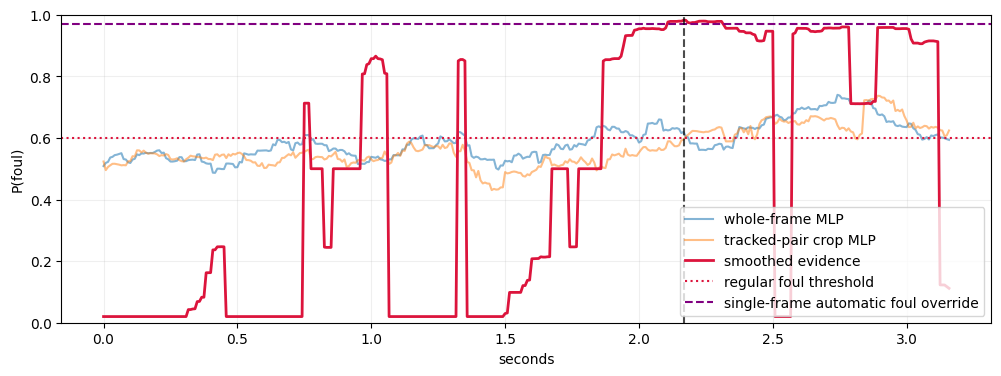

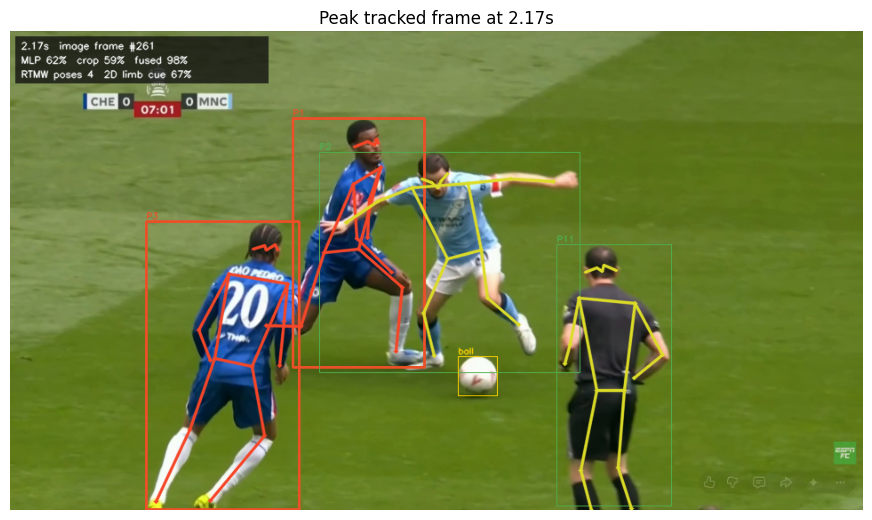

In [17]:
from google.colab import files
from IPython.display import Video, display
import cv2
import matplotlib.pyplot as plt

from airef.tracked_video import judge_video

HIGH_CONFIDENCE_OVERRIDE = 0.97  #@param {type:"number"}

uploaded = files.upload()
for name, data in uploaded.items():
    if not name.lower().endswith((".mp4", ".mov", ".m4v", ".avi")):
        print("Skipping non-video:", name)
        continue

    result = judge_video(
        data,
        yolo_weights=TRACKER_MODEL,
        tracker="botsort.yaml",
        pose_model=str(POSE_MODEL),
        skeleton_weights=SKELETON_MODEL,
        frame_threshold=0.60,
        minimum_seconds=0.12,
        high_confidence_override=HIGH_CONFIDENCE_OVERRIDE,
        max_frames=None,
        make_video=True,
        progress=print,
    )
    print("\n" + "=" * 72)
    print(result.report)
    print("=" * 72)

    times = [row["time"] for row in result.timeline]
    scene = [row["scene_foul"] for row in result.timeline]
    crop = [row["pair_crop_foul"] for row in result.timeline]
    evidence = [row["evidence"] for row in result.timeline]
    plt.figure(figsize=(12, 4))
    plt.plot(times, scene, alpha=0.55, label="whole-frame MLP")
    plt.plot(times, crop, alpha=0.50, label="tracked-pair crop MLP")
    plt.plot(times, evidence, color="crimson", lw=2, label="smoothed evidence")
    plt.axhline(0.60, color="crimson", ls=":", label="regular foul threshold")
    plt.axhline(
        HIGH_CONFIDENCE_OVERRIDE, color="purple", ls="--",
        label="single-frame automatic foul override",
    )
    plt.axvline(result.peak_time, color="black", ls="--", alpha=0.7)
    plt.ylim(0, 1)
    plt.xlabel("seconds")
    plt.ylabel("P(foul)")
    plt.grid(alpha=0.2)
    plt.legend()
    plt.show()

    if result.peak_frame is not None:
        plt.figure(figsize=(11, 7))
        plt.imshow(cv2.cvtColor(result.peak_frame, cv2.COLOR_BGR2RGB))
        plt.title(f"Peak tracked frame at {result.peak_time:.2f}s")
        plt.axis("off")
        plt.show()

    if result.annotated_video:
        display(Video(result.annotated_video, embed=True))

## v2Prototype decision order

1. If the restored per-frame fusion says `FOUL` and fused evidence is at least
   `HIGH_CONFIDENCE_OVERRIDE` (default 97%), call `FOUL` immediately.
2. Otherwise, use the vPrototype repeated SAM 2 + MoGe-2 metric-contact rule.
3. If geometry is separated, return `NO FOUL`.
4. If geometry is occluded or ambiguous, return `NEEDS REVIEW`.

The automatic override deliberately outranks the depth veto. Lowering it will
increase recall but can restore false positives from 2D overlap. Keep it at
97% or higher unless validation clips demonstrate otherwise.
